In [5]:
import sys
!{sys.executable} -m pip install scikit-learn pandas matplotlib

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df1 = pd.read_csv('PublicidadVentas.csv')
X = df1[['Inversion']]
y = df1['Ventas']

In [7]:
modelo1 = LinearRegression()
modelo1.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
y_pred = modelo1.predict(X)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

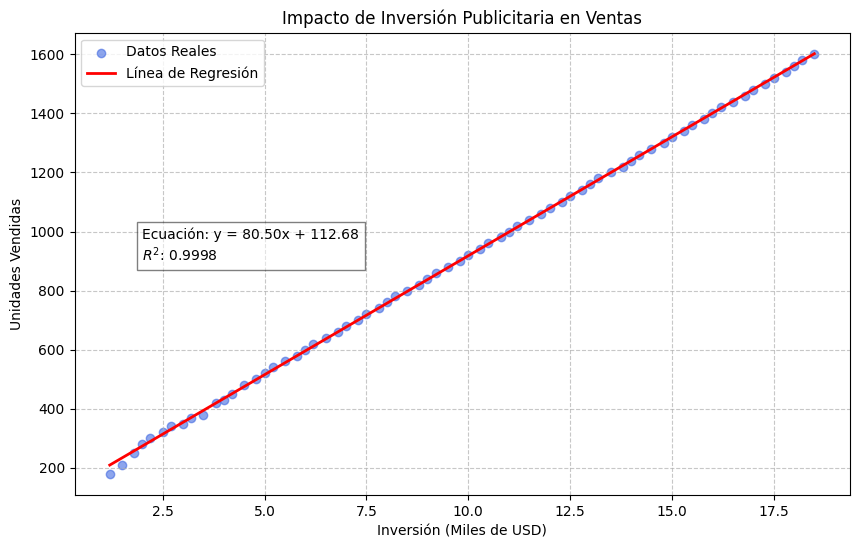

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='royalblue', alpha=0.6, label='Datos Reales')
plt.plot(X, y_pred, color='red', linewidth=2, label='Línea de Regresión')
plt.title('Impacto de Inversión Publicitaria en Ventas')
plt.xlabel('Inversión (Miles de USD)')
plt.ylabel('Unidades Vendidas')
plt.text(2, 900, f'Ecuación: y = {modelo1.coef_[0]:.2f}x + {modelo1.intercept_:.2f}\n$R^2$: {r2:.4f}', 
         bbox=dict(facecolor='white', alpha=0.5))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [10]:
def estimar_ventas(inversion):
    pred = modelo1.predict([[inversion]])
    return pred[0]

print(f"Calidad del Modelo - MSE: {mse:.2f}, R²: {r2:.4f}")
print(f"Predicción para 12k de inversión: {estimar_ventas(12):.2f} unidades")

Calidad del Modelo - MSE: 38.76, R²: 0.9998
Predicción para 12k de inversión: 1078.65 unidades


c:\Users\Mario\Documents\Desatech\Mineria-de-Datos\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
